# Classificação

Importar bibliotecas e matplotlib

In [44]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from scipy.stats import t as t_dist
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report)
import missingno as msno

# Configuração do matplotlib
warnings.filterwarnings('default')
plt.switch_backend('Agg')
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

print('Bibliotecas carregadas com sucesso!')


Bibliotecas carregadas com sucesso!


# carregar dados

In [45]:
df = pd.read_csv('processed_lisboa_porto_air_quality.csv', sep=';')

# 1º Modelo regressão

In [46]:
df.columns = df.columns.str.lower()

df_clean = df.dropna(subset=['no2','co','datetime','nox','air_quality_good'])

print(f'Dataset: {df_clean.shape[0]} observações × {df_clean.shape[1]} variáveis')
print(df_clean['air_quality_good'].value_counts())

Dataset: 7258 observações × 20 variáveis
air_quality_good
False    5192
True     2066
Name: count, dtype: int64


# 1º Selecionar variaveis numéricas para análise

In [47]:
df_clean['datetime'] = pd.to_datetime(df_clean['datetime'])

# criar variáveis temporais
df_clean['hour'] = df_clean['datetime'].dt.hour
df_clean['day'] = df_clean['datetime'].dt.month
df_clean['month'] = df_clean['datetime'].dt.day



features = [
    'co','day', 'month', 'hour','nox','no2'
]
X = df_clean[features]
y = df_clean['air_quality_good']   

# 9157 observações
print("Shape:", X.shape)

#12 features
print(f"Features: {X.shape[1]}")
## Verificar NaNs
print("NaNs antes:")
print(X.isnull().sum())



Shape: (7258, 6)
Features: 6
NaNs antes:
co       0
day      0
month    0
hour     0
nox      0
no2      0
dtype: int64


/var/folders/n2/px9qwf2j01x588j60m5_pzyw0000gn/T/ipykernel_1502/61303679.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['datetime'] = pd.to_datetime(df_clean['datetime'])


# 2º Modelo Classificação

In [48]:
df.columns = df.columns.str.lower()

df_clean2 = df.dropna(subset=['datetime','temperature_c','humidity_percent','c6h6','air_quality_good'])
print(f'Dataset: {df_clean2.shape[0]} observações × {df_clean2.shape[1]} variáveis')
print(df_clean2['air_quality_good'].value_counts())

Dataset: 8991 observações × 20 variáveis
air_quality_good
False    6136
True     2855
Name: count, dtype: int64


# 2º Selecionar variaveis numéricas para análise

In [49]:
df_clean2['datetime'] = pd.to_datetime(df_clean2['datetime'])

# criar variáveis temporais
df_clean2['hour'] = df_clean2['datetime'].dt.hour
df_clean2['day'] = df_clean2['datetime'].dt.month
df_clean2['month'] = df_clean2['datetime'].dt.day

y1 = df_clean2['air_quality_good']

features2 = ['temperature_c','humidity_percent','c6h6','hour', 'day', 'month'
]

X1 = df_clean2[features2]
    
# 9157 observações
print("Shape:", X1.shape)

#12 features
print(f"Features: {X1.shape[1]}")
## Verificar NaNs
print("NaNs antes:")
print(X1.isnull().sum())



Shape: (8991, 6)
Features: 6
NaNs antes:
temperature_c       0
humidity_percent    0
c6h6                0
hour                0
day                 0
month               0
dtype: int64


/var/folders/n2/px9qwf2j01x588j60m5_pzyw0000gn/T/ipykernel_1502/1005847088.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean2['datetime'] = pd.to_datetime(df_clean2['datetime'])


# Dividir Dados 1º Modelo

In [50]:
test_size = 0.2  # 20% para teste
random_state = 42  # para reprodutibilidade

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, stratify=y
)

print(f"Conjunto de treino: {len(X_train)} amostras")
print(f"Conjunto de teste: {len(X_test)} amostras")
print(f"Proporção classe positiva (treino): {y_train.mean():.3f}")
print(f"Proporção classe positiva (teste): {y_test.mean():.3f}")

Conjunto de treino: 5806 amostras
Conjunto de teste: 1452 amostras
Proporção classe positiva (treino): 0.285
Proporção classe positiva (teste): 0.284


# Treino do 1º Modelo de Regressão Logística

In [51]:
# Instanciar o modelo

model = make_pipeline(
    # normalização das variáveis
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

# Treinar o modelo
model.fit(X_train, y_train)

# Fazer previsões
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # probabilidade da classe positiva

print("Modelo treinado com sucesso!")
print(f"Exatidão do modelo: {model.score(X_test, y_test):.4f}")

Modelo treinado com sucesso!
Exatidão do modelo: 0.8650


# Avaliação do 1º Modelo

In [52]:
# Calcular métricas básicas

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MÉTRICAS DE AVALIAÇÃO DO MODELO")
print("=" * 45)
print(f"Exatidão (Accuracy):     {accuracy:.4f}")
print(f"Precisão (Precision):    {precision:.4f}")
print(f"Sensibilidade (Recall):  {recall:.4f}")
print(f"F1-Score:               {f1:.4f}")
print("=" * 45)

# Relatório detalhado
print("\n RELATÓRIO DETALHADO:")
print(classification_report(y_test, y_pred, target_names=['Classe 0', 'Classe 1']))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
print("\n MATRIZ DE CONFUSÃO:")
print(f"              Previsto")
print(f"          0       1")
print(f"Real 0  {cm[0,0]:4d}   {cm[0,1]:4d}")
print(f"     1  {cm[1,0]:4d}   {cm[1,1]:4d}")

MÉTRICAS DE AVALIAÇÃO DO MODELO
Exatidão (Accuracy):     0.8650
Precisão (Precision):    0.7719
Sensibilidade (Recall):  0.7458
F1-Score:               0.7586

 RELATÓRIO DETALHADO:
              precision    recall  f1-score   support

    Classe 0       0.90      0.91      0.91      1039
    Classe 1       0.77      0.75      0.76       413

    accuracy                           0.87      1452
   macro avg       0.84      0.83      0.83      1452
weighted avg       0.86      0.87      0.86      1452


 MATRIZ DE CONFUSÃO:
              Previsto
          0       1
Real 0   948     91
     1   105    308


# Dividir Dados 2º Modelo

In [53]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)

print(f"Conjunto de treino: {len(X1_train)} amostras")
print(f"Conjunto de teste: {len(X1_test)} amostras")
print(f"Proporção classe positiva (treino): {y1_train.mean():.3f}")
print(f"Proporção classe positiva (teste): {y1_test.mean():.3f}")


Conjunto de treino: 7192 amostras
Conjunto de teste: 1799 amostras
Proporção classe positiva (treino): 0.318
Proporção classe positiva (teste): 0.317


# Treino do 2º Modelo de Regressão Logística

In [54]:

model2 = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

model2.fit(X1_train, y1_train)

y2_pred = model2.predict(X1_test)
y2_pred_proba = model2.predict_proba(X1_test)[:, 1]

print("Modelo treinado com sucesso!")
print(f"Exatidão do modelo: {model2.score(X1_test, y1_test):.4f}")

Modelo treinado com sucesso!
Exatidão do modelo: 0.9288


# Avaliação do 2º Modelo

In [55]:
# Calcular métricas básicas

accuracy1 = accuracy_score(y1_test, y2_pred)
precision1 = precision_score(y1_test, y2_pred)
recall1 = recall_score(y1_test, y2_pred)
f11 = f1_score(y1_test, y2_pred)

print("MÉTRICAS DE AVALIAÇÃO DO MODELO")
print("=" * 45)
print(f"Exatidão (Accuracy):     {accuracy1:.4f}")
print(f"Precisão (Precision):    {precision1:.4f}")
print(f"Sensibilidade (Recall):  {recall1:.4f}")
print(f"F1-Score:               {f11:.4f}")
print("=" * 45)

# Relatório detalhado
print("\n RELATÓRIO DETALHADO:")
print(classification_report(y1_test, y2_pred, target_names=['Classe 0', 'Classe 1']))

# Matriz de confusão
cm = confusion_matrix(y1_test, y2_pred)
print("\n MATRIZ DE CONFUSÃO:")
print(f"              Previsto")
print(f"          0       1")
print(f"Real 0  {cm[0,0]:4d}   {cm[0,1]:4d}")
print(f"     1  {cm[1,0]:4d}   {cm[1,1]:4d}")

MÉTRICAS DE AVALIAÇÃO DO MODELO
Exatidão (Accuracy):     0.9288
Precisão (Precision):    0.8879
Sensibilidade (Recall):  0.8879
F1-Score:               0.8879

 RELATÓRIO DETALHADO:
              precision    recall  f1-score   support

    Classe 0       0.95      0.95      0.95      1228
    Classe 1       0.89      0.89      0.89       571

    accuracy                           0.93      1799
   macro avg       0.92      0.92      0.92      1799
weighted avg       0.93      0.93      0.93      1799


 MATRIZ DE CONFUSÃO:
              Previsto
          0       1
Real 0  1164     64
     1    64    507


# Modelo 3 de Random Forest

# Dividir Modelo

In [56]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)

print(f"Conjunto de treino: {len(X1_train)} amostras")
print(f"Conjunto de teste: {len(X1_test)} amostras")
print(f"Proporção classe positiva (treino): {y1_train.mean():.3f}")
print(f"Proporção classe positiva (teste): {y1_test.mean():.3f}")



Conjunto de treino: 7192 amostras
Conjunto de teste: 1799 amostras
Proporção classe positiva (treino): 0.318
Proporção classe positiva (teste): 0.317


# Treinar 3º Modelo

In [57]:
from sklearn.ensemble import RandomForestClassifier


# Criar modelo
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    class_weight='balanced'
)

# Treinar
rf_model.fit(X1_train, y1_train)

# Previsões
y3_pred = rf_model.predict(X1_test)



# Avaliação do 3º Modelo

In [58]:
# Calcular métricas básicas

accuracy1 = accuracy_score(y1_test, y3_pred)
precision1 = precision_score(y1_test, y3_pred)
recall1 = recall_score(y1_test, y3_pred)
f11 = f1_score(y1_test, y3_pred)

print("MÉTRICAS DE AVALIAÇÃO DO MODELO")
print("=" * 45)
print(f"Exatidão (Accuracy):     {accuracy1:.4f}")
print(f"Precisão (Precision):    {precision1:.4f}")
print(f"Sensibilidade (Recall):  {recall1:.4f}")
print(f"F1-Score:               {f11:.4f}")
print("=" * 45)

# Relatório detalhado
print("\n RELATÓRIO DETALHADO:")
print(classification_report(y1_test, y3_pred, target_names=['Classe 0', 'Classe 1']))

# Matriz de confusão
cm = confusion_matrix(y1_test, y3_pred)
print("\n MATRIZ DE CONFUSÃO:")
print(f"              Previsto")
print(f"          0       1")
print(f"Real 0  {cm[0,0]:4d}   {cm[0,1]:4d}")
print(f"     1  {cm[1,0]:4d}   {cm[1,1]:4d}")

MÉTRICAS DE AVALIAÇÃO DO MODELO
Exatidão (Accuracy):     0.9800
Precisão (Precision):    1.0000
Sensibilidade (Recall):  0.9370
F1-Score:               0.9675

 RELATÓRIO DETALHADO:
              precision    recall  f1-score   support

    Classe 0       0.97      1.00      0.99      1228
    Classe 1       1.00      0.94      0.97       571

    accuracy                           0.98      1799
   macro avg       0.99      0.97      0.98      1799
weighted avg       0.98      0.98      0.98      1799


 MATRIZ DE CONFUSÃO:
              Previsto
          0       1
Real 0  1228      0
     1    36    535


# Visualizar os datasets

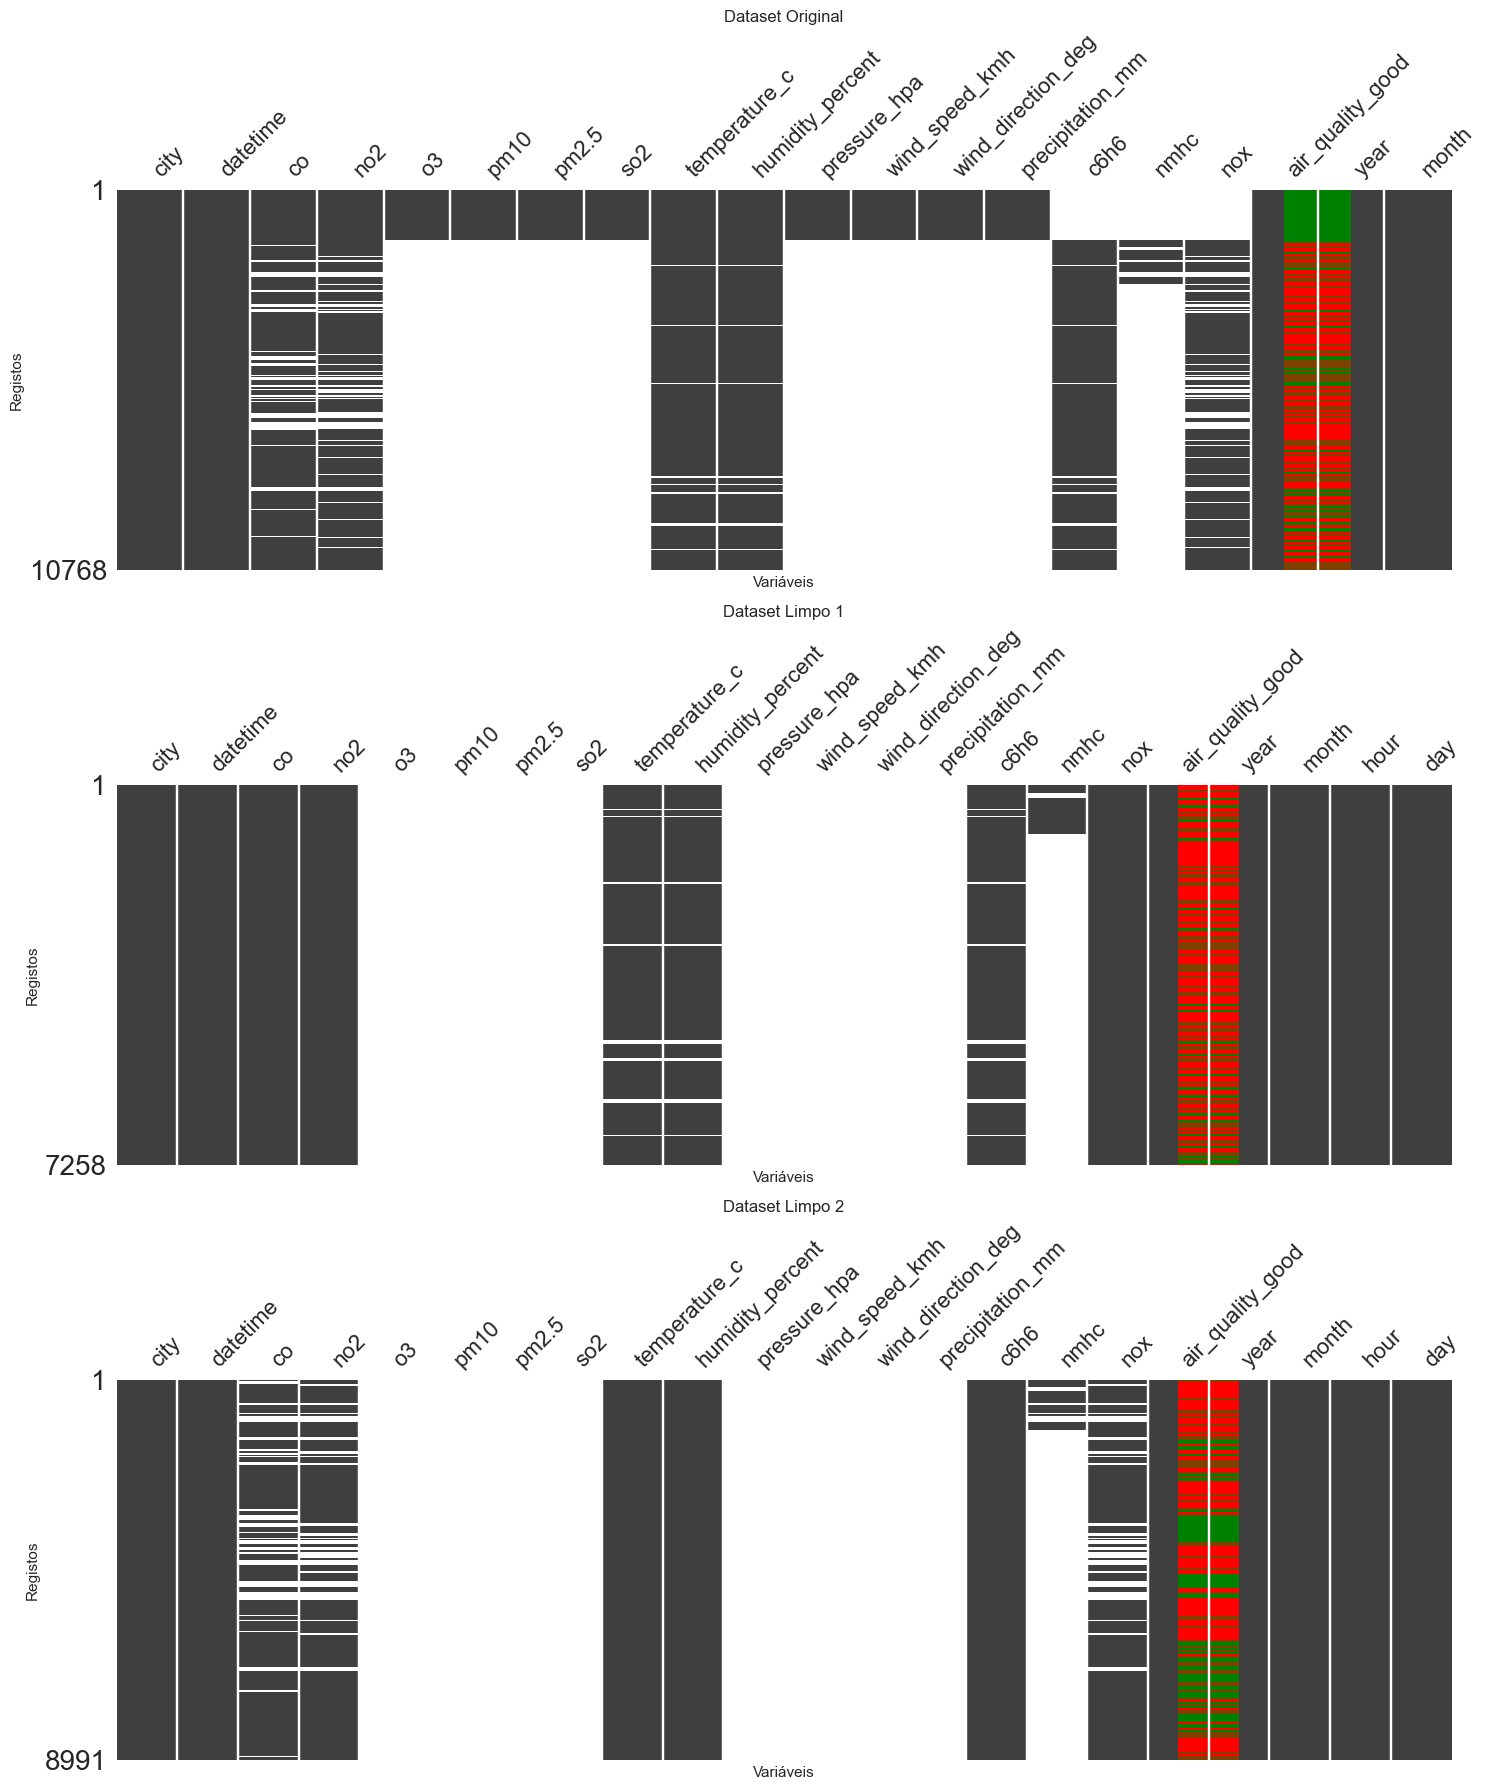

In [59]:
%matplotlib inline

fig, axes = plt.subplots(3, 1, figsize=(15, 18))

def color_boolean_column(ax, dataframe, column_name):

    # posição da coluna
    col_index = dataframe.columns.get_loc(column_name)

    # desenhar células coloridas
    for i, val in enumerate(dataframe[column_name]):

        if pd.isna(val):
            color = "white"

        elif val == True:
            color = "green"

        else:
            color = "red"

        ax.add_patch(
            plt.Rectangle(
                (col_index, i),
                1,
                1,
                color=color,
                ec=None
            )
        )


# Gráfico 1
msno.matrix(
    df,
    ax=axes[0],
    sparkline=False
)

color_boolean_column(
    axes[0],
    df,
    "air_quality_good"
)

axes[0].set_title("Dataset Original")
axes[0].set_xlabel("Variáveis")
axes[0].set_ylabel("Registos")

# Gráfico 2
msno.matrix(
    df_clean,
    ax=axes[1],
    sparkline=False
)

color_boolean_column(
    axes[1],
    df_clean,
    "air_quality_good"
)

axes[1].set_title("Dataset Limpo 1")
axes[1].set_xlabel("Variáveis")
axes[1].set_ylabel("Registos")

# Gráfico 3
msno.matrix(
    df_clean2,
    ax=axes[2],
    sparkline=False
)

color_boolean_column(
    axes[2],
    df_clean2,
    "air_quality_good"
)

axes[2].set_title("Dataset Limpo 2")
axes[2].set_xlabel("Variáveis")
axes[2].set_ylabel("Registos")

plt.tight_layout()
plt.show()


# Guardar dados

In [62]:
import os
import pandas as pd
import pickle
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
# Criar pasta para guardar resultados

folder_name = "classification_results"

os.makedirs(folder_name, exist_ok=True)

# Metricas para os modelos

# Modelo 1
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Modelo 2
accuracy1 = accuracy_score(y1_test, y2_pred)
precision1 = precision_score(y1_test, y2_pred)
recall1 = recall_score(y1_test, y2_pred)
f11 = f1_score(y1_test, y2_pred)

# Modelo 3
accuracy2 = accuracy_score(y1_test, y3_pred)
precision2 = precision_score(y1_test, y3_pred)
recall2 = recall_score(y1_test, y3_pred)
f12 = f1_score(y1_test, y3_pred)

# Guardar métricas numéricas em CSV

metrics = pd.DataFrame({
    "model": [
        "Logistic Regression 1",
        "Logistic Regression 2",
        "Random Forest 3"
    ],
    "accuracy": [
        accuracy,
        accuracy1,
        accuracy2
    ],
    "precision": [
        precision,
        precision1,
        precision2
    ],
    "recall": [
        recall,
        recall1,
        recall2
    ],
    "f1_score": [
        f1,
        f11,
        f12
    ]
})

metrics.to_csv(
    f"{folder_name}/metrics_classification.csv",
    index=False
)

print("Métricas guardadas")

# Guadar pickles

with open(f"{folder_name}/classification_model1.pkl", "wb") as f:
    pickle.dump(model, f)

with open(f"{folder_name}/classification_model2.pkl", "wb") as f:
    pickle.dump(model2, f)

with open(f"{folder_name}/classification_model3.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("Modelos guardados")

Métricas guardadas
Modelos guardados
